# 라이브러리 임포트
##### 실습에 필요한 라이브러리를 임포트

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config
set_config(display='text')

import warnings
warnings.filterwarnings('ignore')

## 데이터 불러오기(학습데이터, 테스트데이터)

In [31]:
train = pd.read_csv('basketball_train.csv')
test = pd.read_csv('basketball_test.csv')

print(train.head())
print(test.head())

print(train.shape[0])
print(test.shape[0])


            Player Pos   3P  TRB  BLK
0   Dewayne Dedmon   C  0.0  6.5  0.8
1    Manu Ginobili  SG  1.3  2.3  0.2
2      Salah Mejri   C  0.0  4.2  0.8
3     Nene Hilario   C  0.0  4.2  0.6
4  Jordan Crawford  SG  1.9  1.8  0.1
            Player Pos   3P  TRB  BLK
0      Danny Green  SG  1.7  3.3  0.8
1  Marco Belinelli  SG  1.4  2.4  0.1
2     Bradley Beal  SG  2.9  3.1  0.3
3      Buddy Hield  SG  1.8  3.3  0.1
4      Kyle Korver  SG  2.4  2.8  0.3
80
20


## SVM 최적의 파라미터 찾기

##### 1. C(cost, 비용) : 결정경계선의 마진을 결정하는 파라미터.
##### 2. gamma : 커널의 데이터포인트 표준 편차를 결정하는 조절 변수

In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

In [34]:
# sklearn에서 제공하는 GridSearchCV를 사용하면, 
# 손쉽게 최적의 C, gamma를 구할 수 있음.

def svc_param_selection(X, y, nfolds):
    """
    GridSearchCV를 활용하여 RBF 커널 SVM의 최적 C, gamma 파라미터를 탐색하는 함수
    
    :param X: 특성 데이터 (Feature data)
    :param y: 라벨 데이터 (Target data)
    :param nfolds: 교차 검증(Cross Validation) 분할 수
    :return: 최적의 파라미터로 학습이 완료된 GridSearchCV 객체
    """
    svm_parameters = [
        {
            'kernel': ['rbf'],  # 커널 트릭의 RBF 알고리즘
            'gamma': [0.00001, 0.0001, 0.001, 0.01, 0.1, 1],
            'C': [0.01, 0.1, 1, 10, 100, 1000]
        }
    ]
    
    # SVC 모델에 대해 지정한 파라미터 조합을 교차 검증으로 평가
    clf = GridSearchCV(SVC(), svm_parameters, cv=nfolds)
    clf.fit(X, y)
    
    print("최적의 결정경계:", clf.best_params_)
    # print("최적의 최고 정확도:", clf.best_score_)
    
    return clf

In [35]:
X_train = train[['3P', 'BLK']]
y_train = train[['Pos']] # 정답 데이터

# 최적의 파라미터를 sklearn의 GridSearchCV를 통해 구한다
clf = svc_param_selection(X_train, y_train, 10)

최적의 결정경계: {'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}


## 시각화
##### 최적의 파라미터일 때의 결정경계선과, 다른 파라미터들일 때의 결정 경계선을 비교.

In [36]:
# 시각화를 하기 위해, 최적의 C와 최적의 C를 비교하기 위한 다른 C를 후보로 저장.
C_candidates = []
C_candidates.append(clf.best_params_['C'] * 0.01)   # C : 0.1 * 0.01 = 0.001
C_candidates.append(clf.best_params_['C'])  # C : 0.1
C_candidates.append(clf.best_params_['C'] * 100)  # C : 0.1 * 100 = 10

# 0.001, 0.1, 10

In [37]:
# 시각화를 하기 위해, 최적의 gamma와 최적의 gamma를 비교하기 위한 다른 C를 후보로 저장.
gamma_candidates = []
gamma_candidates.append(clf.best_params_['gamma'] * 0.01)  # 'gamma': 1 * 0.01 = 
gamma_candidates.append(clf.best_params_['gamma'])
gamma_candidates.append(clf.best_params_['gamma'] * 100)

In [38]:
X = train[['3P', 'BLK']]  # 훈련 데이터
Y = train['Pos'].tolist()  

In [39]:
# 포지션에 해당하는 문자열 SG와 C를 벡터화합니다.
position = []

for i in Y:
    if i == 'C':
        position.append(0) # cost
    else:
        position.append(1)  # gamma
        
# 각각의 파라미터에 해당하는 SVM 모델을 만들어 classifiers에 저장.
classifiers = []

for C in C_candidates:  # 3개 데이터 최적화 : 값을 기준으로 작은 값, 큰 값
    for gamma in gamma_candidates:  # 3개 데이터
        clf = SVC(C=C, gamma = gamma)  # 튜닝 값은 Cost와 gamma
        clf.fit(X, Y)
        classifiers.append((C, gamma, clf))

# 최적의 결정경계: {'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}
print(classifiers)        

[(0.001, 0.01, SVC(C=0.001, gamma=0.01)), (0.001, 1, SVC(C=0.001, gamma=1)), (0.001, 100, SVC(C=0.001, gamma=100)), (0.1, 0.01, SVC(C=0.1, gamma=0.01)), (0.1, 1, SVC(C=0.1, gamma=1)), (0.1, 100, SVC(C=0.1, gamma=100)), (10.0, 0.01, SVC(C=10.0, gamma=0.01)), (10.0, 1, SVC(C=10.0, gamma=1)), (10.0, 100, SVC(C=10.0, gamma=100))]


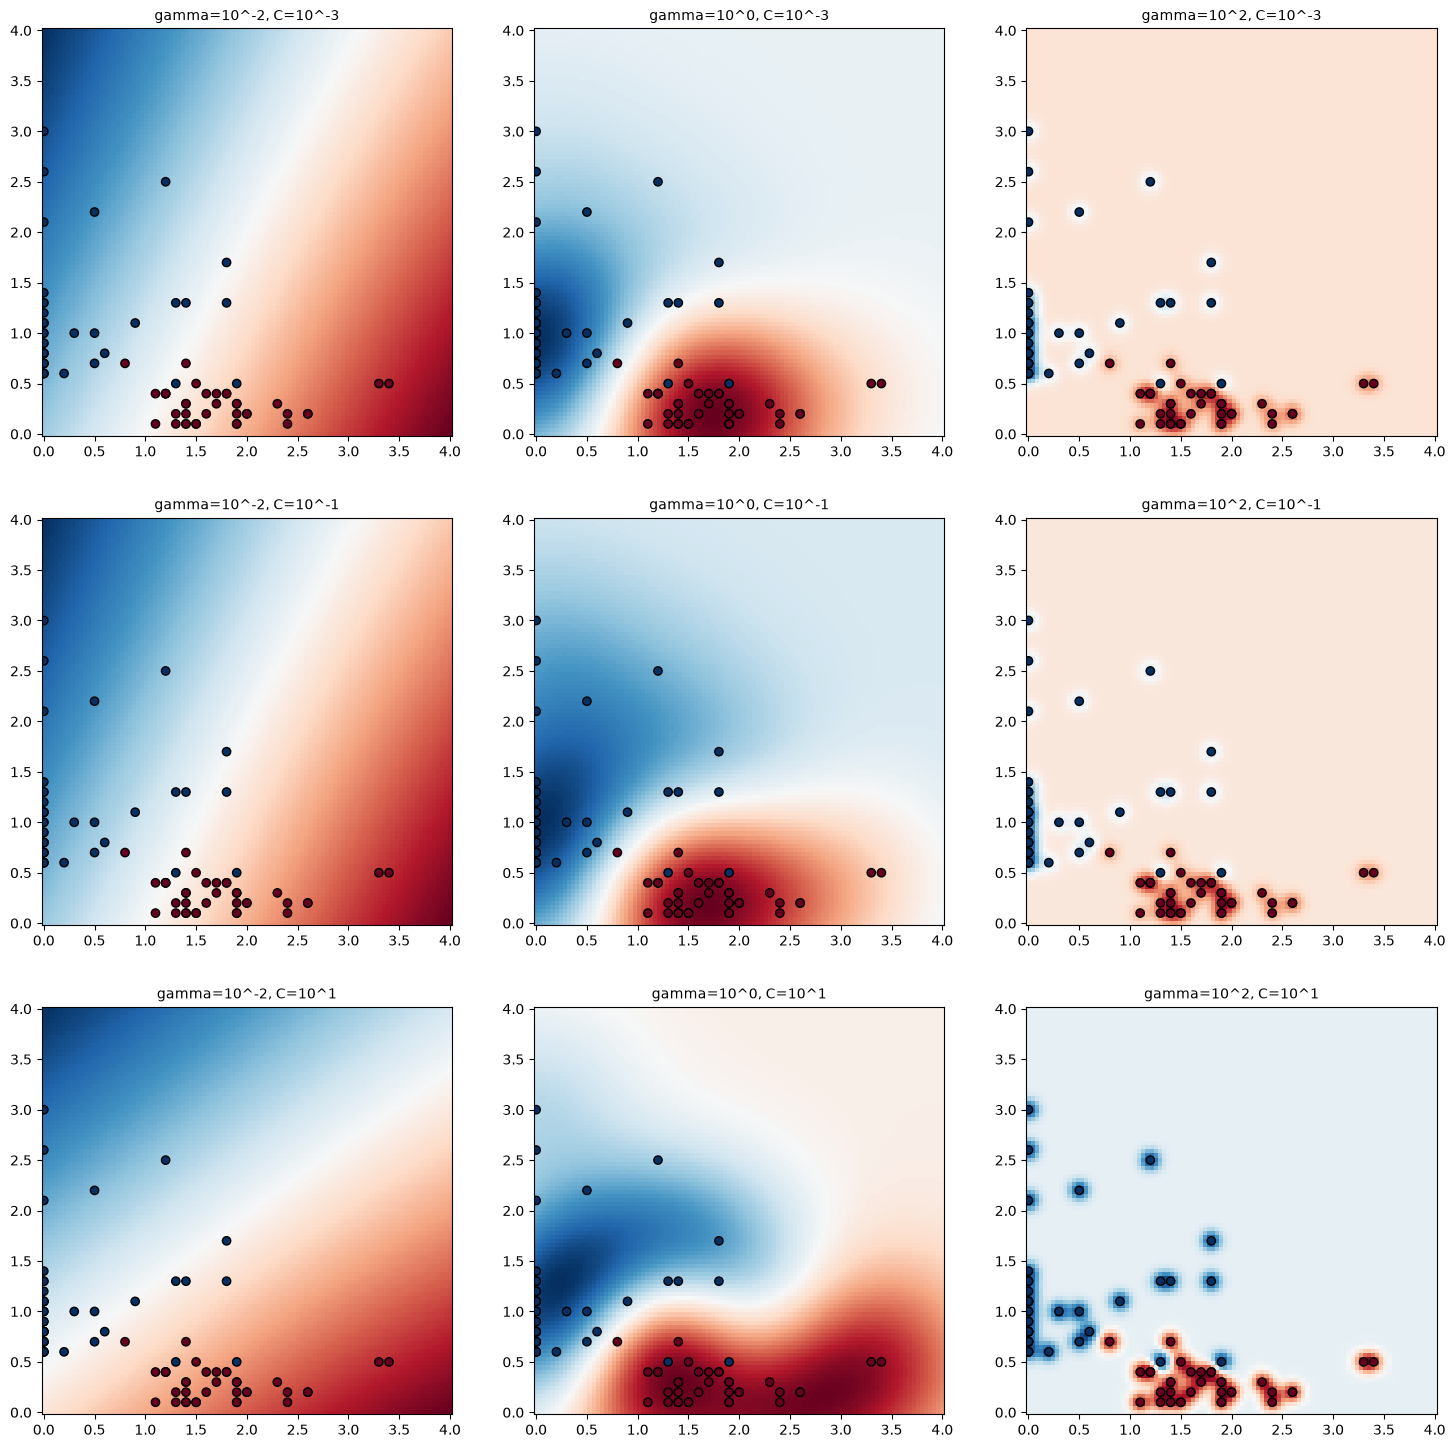

In [ ]:
# 18,18 사이즈의 차트를 구성합니다.
plt.figure(figsize=(18, 18))
xx, yy = np.meshgrid(np.linspace(0, 4, 100), np.linspace(0, 4, 100))  # 100개의 눈금자

# 각각의 모델들에 대한 결정 경계 함수를 적용하여 함께 시각화합니다.
for (k, (C, gamma, clf)) in enumerate(classifiers):
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # 최적의 모델을 포함한 다른 파라미터로 학습된 모델들을 함께 시각화해봅니다.
    plt.subplot(len(C_candidates), len(gamma_candidates), k + 1)  # 9개, 인덱스는 1부터
    plt.title("gamma=10^%d, C=10^%d" % (np.log10(gamma), np.log10(C)),
              size='medium')

    # 서포트 벡터와 결정경계선을 시각화합니다.
    plt.pcolormesh(xx, yy, -Z, cmap=plt.cm.RdBu) # 2D 배열 플로팅(cmap="plasma")
    plt.scatter(X['3P'], X['BLK'], c=position, cmap=plt.cm.RdBu_r, edgecolors='k')

## 테스트
##### sklearn의 gridsearchcv로 얻어진 최적의 파라미터로 학습된 clf를 이용하여, 테스트를 진행

In [40]:
# 테스트에 사용될 특징을 지정
X_test = test[['3P', 'BLK']]  # 20개 데이터
y_test = test[['Pos']]

pred = clf.predict(X_test) # predict() 예측의 성능 확인
# pred

In [41]:
comparison = pd.DataFrame({'예측값':pred, \
                           '정답':y_test.values.ravel()})
comparison

,예측값,정답
0,C,SG
1,SG,SG
2,C,SG
3,SG,SG
4,SG,SG
5,SG,C
6,SG,SG
7,SG,C
8,C,C
9,SG,SG


In [42]:
# check accuracy
print('accuracy : ' + str(accuracy_score(pred, y_test.values.ravel())))

accuracy : 0.75


In [ ]:
print(classification_report(y_test, pred)) # 예측 데이터, 정답 데이터

              precision    recall  f1-score   support

           C       0.62      0.71      0.67         7
          SG       0.83      0.77      0.80        13

    accuracy                           0.75        20
   macro avg       0.73      0.74      0.73        20
weighted avg       0.76      0.75      0.75        20

